https://stackoverflow.com/questions/74141355/dimensionality-reduction-autoencoder-pytorch

#### Imports

In [11]:
import importlib
import time
import copy
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.gaussian_process import GaussianProcessRegressor

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

Current device: cuda


In [12]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [13]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [14]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))
X_tr, X_val, Y_tr, Y_val = train_test_split(X, Y_resh, test_size=0.2, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (100, 9)
Y_tr shape: (400, 6, 4205)
Y_val shape: (100, 6, 4205)


#### Gaussian Process Pipeline

<ol>
    <li><b>Dimensionality Reduction</b>: PCA and Kernel PCA are implemented. From testing and research, it can be seen that 10 components already explain over 99.99% of variance.</li>
    <li><b>Scaling</b>: standard scaling and min-max scaling are implemented.</li>
    <li><b>Fit</b> of the Gaussian Processes.</li>
    <li><b>Validation</b> of the Gaussian Processes.</li>
</ol>

In [15]:
def fit_gp(x_tr_scaled, y_tr_reduced_scaled_list):
    """
    Fit a Gaussian Process Regressor for each output function using the scaled training data
    - inputs: scaled training inputs, list of scaled PCA-transformed training outputs
    - outputs: list of fitted GaussianProcessRegressor models for each output function and the time taken to fit all GPs
    """

    print("========== Fitting Gaussian Process Regressor for each output function... ==========")

    # RBF with length_scale as a vector -> ARD kernel
    n_features = x_tr_scaled.shape[1]
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-5, 1e1))
    )

    # fit Gaussian Process for each function
    gpr_list = []

    # start measuring time
    start_time_fit = time.time()
    for i in range(globals.N_FUNCTIONS):
        gpr = GaussianProcessRegressor(kernel=copy.deepcopy(kernel), n_restarts_optimizer=5, random_state=42)
        gpr.fit(x_tr_scaled, y_tr_reduced_scaled_list[i])
        print("Learned kernel:", gpr.kernel_)
        gpr_list.append(gpr)
    end_time_fit = time.time()
    print(f"Time taken to fit GPs: {end_time_fit - start_time_fit:.2f} seconds")

    print("========== Gaussian Process fitting completed. ==========\n")

    return gpr_list, end_time_fit - start_time_fit

In [16]:
def validate_gp(gpr_list, x_val_scaled, y_val, wavelengths, y_scalers, current_pca_list):
    """
    Validate the fitted Gaussian Process models on the validation set
    - inputs: list of fitted GaussianProcessRegressor models, scaled validation inputs, list of scaled PCA-transformed validation outputs, list of scalers used for each output function, list of PCA objects for each output function
    - outputs: numpy array of predicted outputs on the validation set in the original space (n_samples, 6, 4205)
    """

    print("========== Validating Gaussian Process models on the validation set... ==========")

    # predictions on validation set
    y_val_pred_reduced_scaled_list = []
    for i in range(globals.N_FUNCTIONS):
        y_pred_scaled = gpr_list[i].predict(x_val_scaled)
        y_val_pred_reduced_scaled_list.append(y_pred_scaled)

    # inverse transform predictions to original scale
    y_val_pred_reduced_list = []
    for i in range(globals.N_FUNCTIONS):
        y_pred = y_scalers[i].inverse_transform(y_val_pred_reduced_scaled_list[i])
        y_val_pred_reduced_list.append(y_pred)

    # inverse transform predictions to original space
    y_val_pred_list = []
    if current_pca_list is not None:
        for i in range(globals.N_FUNCTIONS):
            y_pred = current_pca_list[i].inverse_transform(y_val_pred_reduced_list[i])
            y_val_pred_list.append(y_pred)

    y_val_pred = np.stack(y_val_pred_list, axis=1)  # (n_samples, 6, 4205)
    print("y_val_pred shape:", y_val_pred.shape)
    print("NaN values in y_val_pred:", np.isnan(y_val_pred).sum())

    # MRE calculation
    mre = utils.mre_score(y_val, y_val_pred, wavelengths)
    print(f"----- Validation MRE: {mre} -----")

    print("========== Validation completed. ==========\n")

    return y_val_pred, mre

Apply the whole pipeline.

In [7]:
param_grid = {
    "kernel": [None, "rbf", "sigmoid", "poly"],
    "gamma": [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    "alpha": [1e-3, 1e-2, 1e-1, 1],
    "degree": [2, 3, 4],
    "scale_type": ["standard", "minmax"]
}
param_grid = { # for quick testing
    "kernel": [None],
    "gamma": [1e-2],
    "alpha": [0.1],
    "degree": [3],
    "scale_type": ["standard"]
}

last_id = utils.load_csv_last_id("gp_results.csv")
best_mre = float("inf")
best_Y_pred = None

for kernel in param_grid["kernel"]:

    # if regular PCA is used, gamma and alpha are irrelevant
    if kernel is None:
        gamma_values = [None]
        alpha_values = [None]
    else:
        gamma_values = param_grid["gamma"]
        alpha_values = param_grid["alpha"]

    if kernel != "poly":
        degree_values = [0]
    else:
        degree_values = param_grid["degree"]

    for gamma in gamma_values:
        for alpha in alpha_values:
            for degree in degree_values:
                for scale_type in param_grid["scale_type"]:
                    start_time_pipeline = time.time()
                    print(f"========== Running GP pipeline with kernel={kernel}, gamma={gamma}, alpha={alpha}, degree={degree} and scale_type={scale_type}... ==========")

                    # dimensionality reduction
                    pca_list, Y_tr_pca_list, Y_val_pca_list = utils.apply_pca(Y_tr, Y_val, n_components=10, kernel=kernel, gamma=gamma, alpha=alpha, degree=degree)

                    # scaling
                    X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled_list, y_scalers = utils.scale_data(X_tr, X_val, Y_tr_pca_list, scale_type=scale_type)

                    # fit Gaussian Process
                    gpr_list, gp_fit_time = fit_gp(X_tr_scaled, Y_tr_reduced_scaled_list)

                    # validate Gaussian Process
                    Y_pred, mre = validate_gp(gpr_list, X_val_scaled, Y_val, wavelengths, y_scalers, pca_list)

                    # save best model based on MRE
                    if mre < best_mre:
                        best_mre = mre
                        best_Y_pred = Y_pred
                        print(f"New best MRE: {best_mre} with kernel={kernel} and scale_type={scale_type}")

                    # write parameters and MRE to csv file
                    end_time_pipeline = time.time()
                    results_df = pd.DataFrame({
                        "id": [last_id + 1],
                        "kernel": [kernel if kernel is not None else "None"],
                        "gamma": [gamma if gamma is not None else "None"],
                        "alpha": [alpha if alpha is not None else "None"],
                        "degree": [degree if degree != 0 else "None"],
                        "scale_type": [scale_type],
                        "fit_time": [gp_fit_time],
                        "total_time": [end_time_pipeline - start_time_pipeline],
                        "mre": [mre]
                    })
                    results_df.to_csv("gp_results.csv", mode="a", header=not Path("gp_results.csv").exists(), index=False)
                    last_id += 1

========== Running GP pipeline with kernel=None, gamma=None, alpha=None, degree=0 and scale_type=standard... ==========
========== Applying PCA with n_components=10 to each function separately... ==========
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
========== PCA application completed. ==========

========== Scaling data using standard scaling... ==========
========== Scaling completed. ==========

========== Fitting Gaussian Process Regressor for each output function... ==========
Learn

c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 6.73**2 * RBF(length_scale=[30.6, 2.69, 5.54, 1e+03, 5.67, 51.9, 2.27, 19.1, 1.45]) + WhiteKernel(noise_level=0.0196)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 8 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 9.26**2 * RBF(length_scale=[53.2, 1.97, 4.51, 26.5, 6.51, 42.5, 3.8, 54.9, 1e+03]) + WhiteKernel(noise_level=0.000383)
Learned kernel: 7.34**2 * RBF(length_scale=[221, 3.3, 3.45, 14.2, 4.99, 28, 4, 20, 4.05]) + WhiteKernel(noise_level=0.00684)


c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\Matteo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 6 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better valu

Learned kernel: 15.6**2 * RBF(length_scale=[110, 1.35, 5.7, 1e+03, 4.23, 1e+03, 1e+03, 17.4, 1e+03]) + WhiteKernel(noise_level=5.21e-05)
Learned kernel: 9.68**2 * RBF(length_scale=[54.7, 2.69, 5.73, 67.9, 5, 39.1, 3.51, 21.5, 3.49]) + WhiteKernel(noise_level=0.0106)
Time taken to fit GPs: 1468.73 seconds
========== Gaussian Process fitting completed. ==========

========== Validating Gaussian Process models on the validation set... ==========
y_val_pred shape: (400, 6, 4205)
NaN values in y_val_pred: 0
----- Validation MRE: 0.001844629335810059 -----
========== Validation completed. ==========

New best MRE: 0.001844629335810059 with kernel=None and scale_type=standard


Further validation: global average MRE, MRE for each function, MRE for each wavelength.

Validation MRE: 0.001844629335810059
Lp0 MRE: 0.0034
Edir0 MRE: 0.0011
Edif0 MRE: 0.0021
S MRE: 0.0022
tdir MRE: 0.0001
tdif MRE: 0.0021


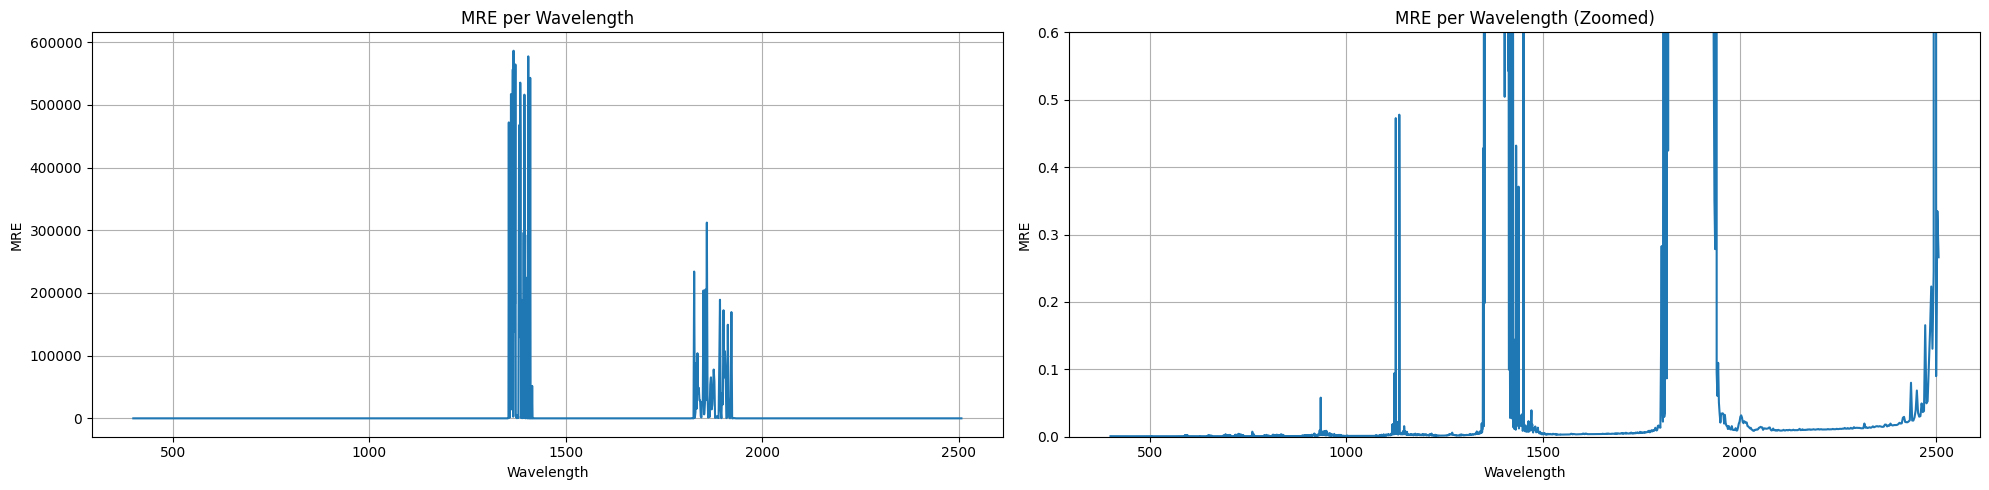

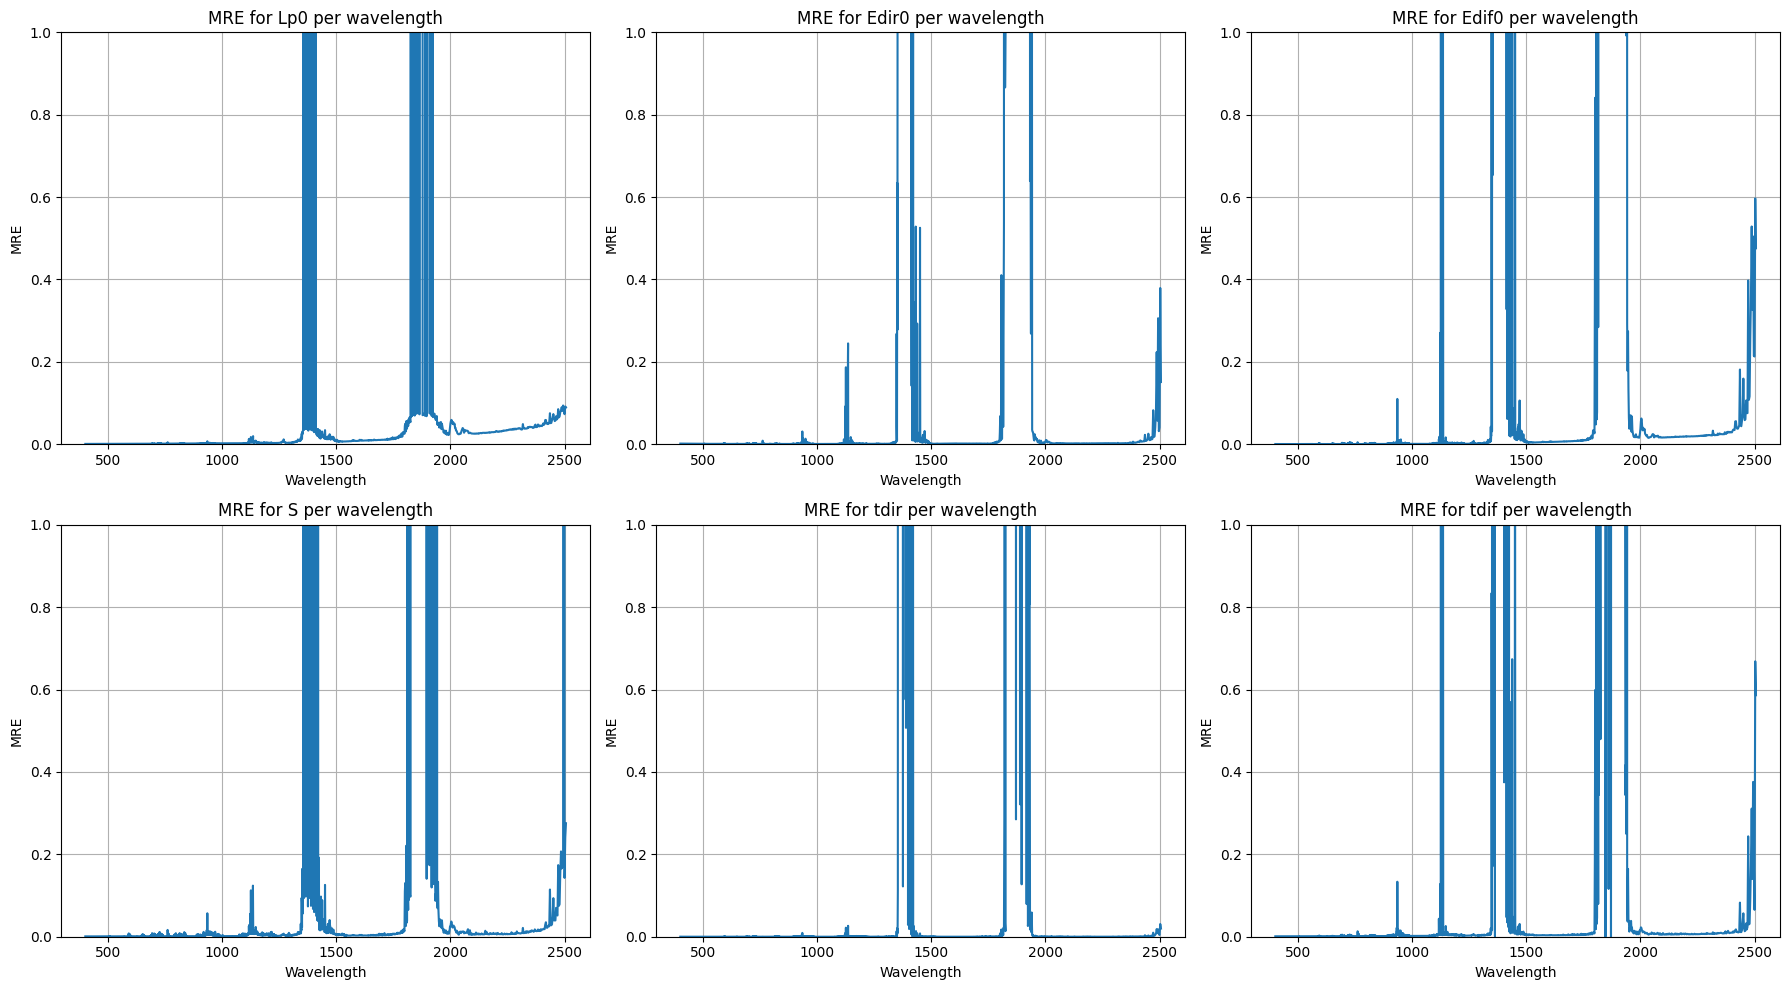

In [8]:
mre = utils.mre_score(Y_val, best_Y_pred, wavelengths)
print("Validation MRE:", mre)

mre_per_func = utils.mre_score(Y_val, best_Y_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names[i]} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = utils.mre_score(Y_val, best_Y_pred, wavelengths, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(wavelengths, mre_per_wvl)
axes[0].set_xlabel("Wavelength")
axes[0].set_ylabel("MRE")
axes[0].set_title("MRE per Wavelength")
axes[0].grid()
axes[1].plot(wavelengths, mre_per_wvl)
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("MRE")
axes[1].set_title("MRE per Wavelength (Zoomed)")
axes[1].grid()
plt.tight_layout()
plt.show()

mre_per_func_wvl = utils.mre_score(Y_val, best_Y_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl[i])
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MRE")
    axes[i].set_title(f"MRE for {function_names[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Validation MAE: 0.14985921731804366
Lp0 MAE: 0.0209
Edir0 MAE: 0.7429
Edif0 MAE: 0.1349
S MAE: 0.0001
tdir MAE: 0.0001
tdif MAE: 0.0003


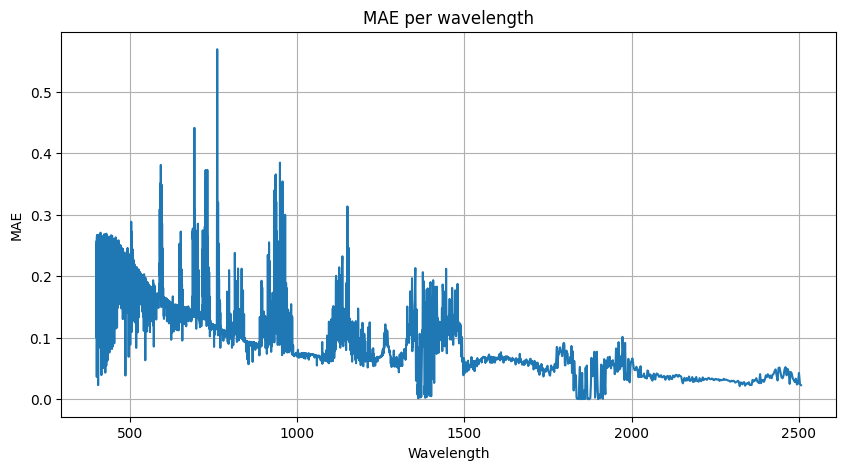

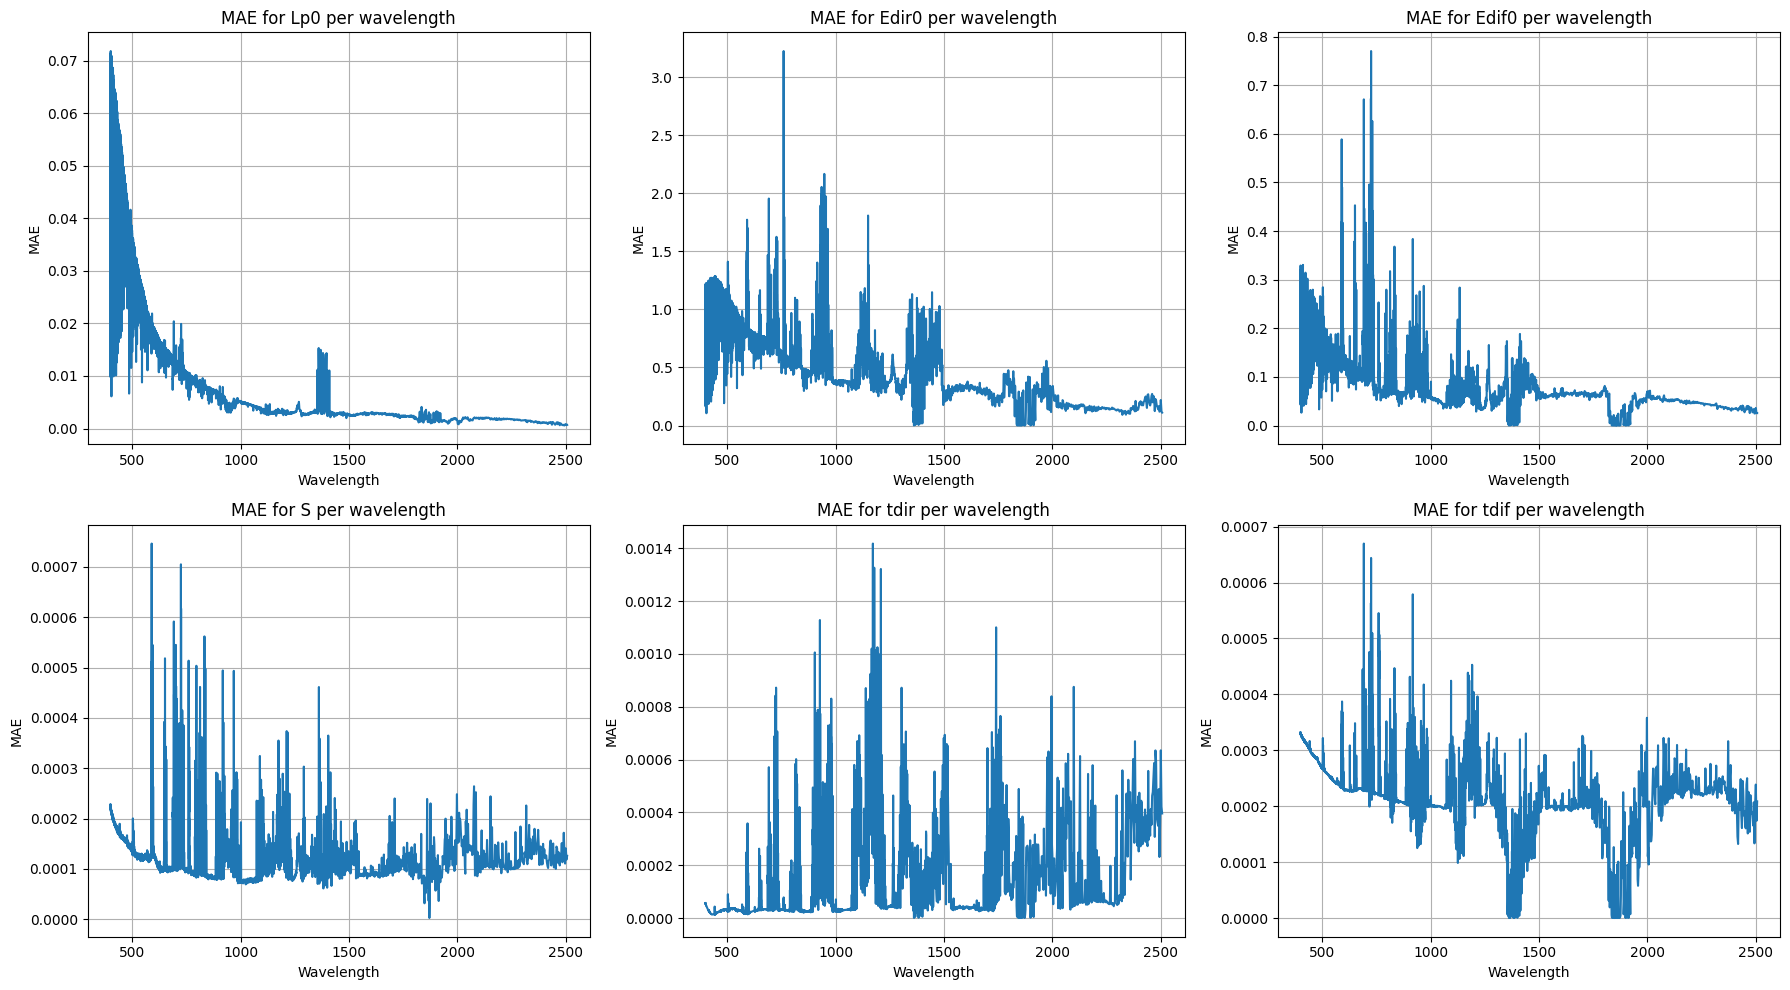

In [9]:
mae = utils.mae_score(Y_val, best_Y_pred, wavelengths)
print("Validation MAE:", mae)


mae_per_func = utils.mae_score(Y_val, best_Y_pred, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names[i]} MAE: {mae_per_func[i]:.4f}")

mae_per_wvl = utils.mae_score(Y_val, best_Y_pred, wavelengths, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

mae_per_func_wvl = utils.mae_score(Y_val, best_Y_pred, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mae_per_func_wvl[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE for {function_names[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

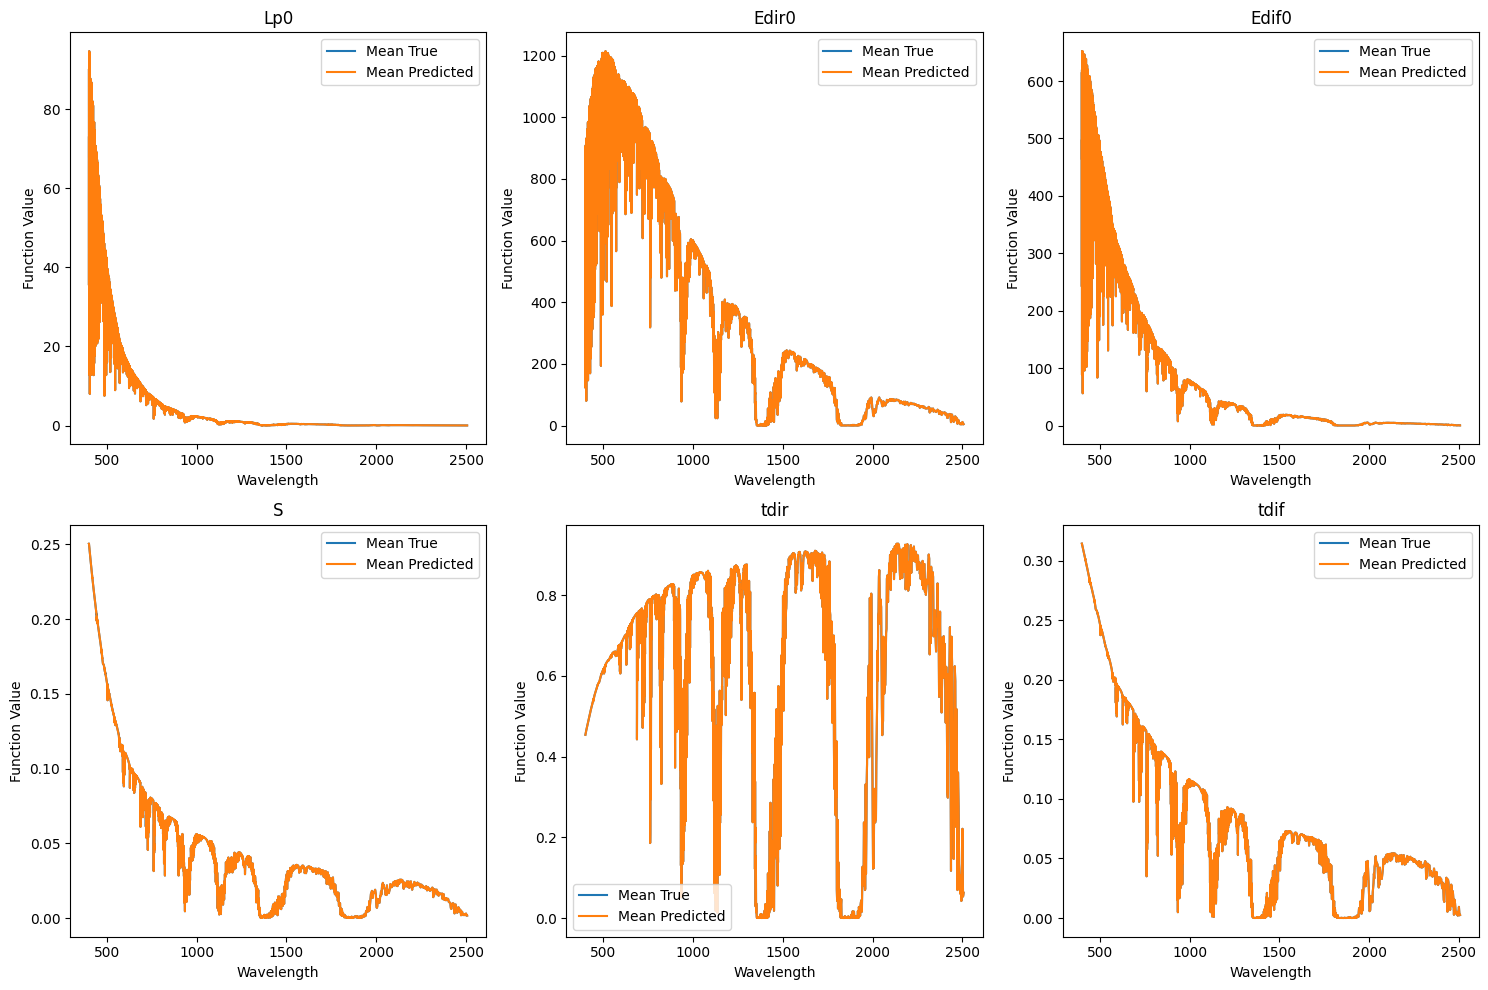

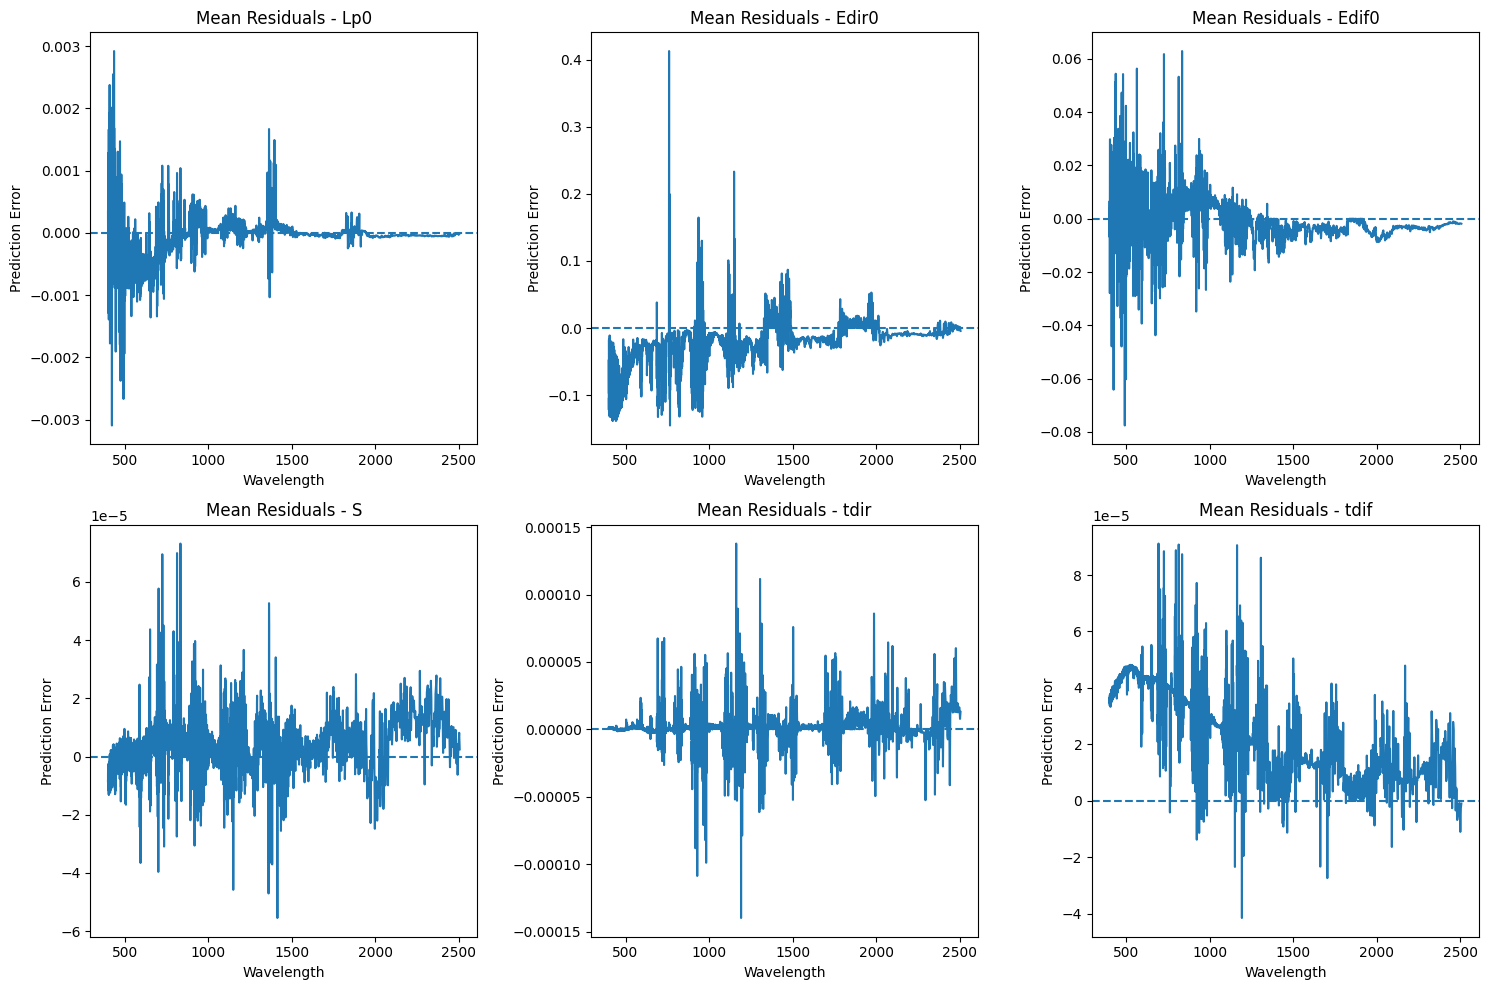

In [10]:
# compute mean true and predicted functions across all samples
Y_true_mean = np.mean(Y_val, axis=0)        # shape: (6, 4205)
Y_pred_mean = np.mean(Y_pred, axis=0)       # shape: (6, 4205)

# plot mean true vs predicted
plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, Y_true_mean[i], label="Mean True")
    plt.plot(wavelengths, Y_pred_mean[i], label="Mean Predicted")

    plt.title(f"{function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()


# residuals for all samples
residuals = Y_pred - Y_val   # shape: (100, 6, 4205)

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()